In [13]:
# Auto-reload modules to ensure we use the latest code
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# Add parent directory to path to import from src/ - DO THIS FIRST
# Get the notebook's directory, then go up one level to project root
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Now import everything - path is set up
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam

# Import PINN models from external module
from src.pinn_models import PressureHeadNet, WaterTableNet, RichardsPINN
# Import normalization helper from external module
from src.normalization_helper import NormalizationHelper
# Import sampling helpers and loss computation functions from external module
from src.training_utils import (
    SamplingHelpers, 
    compute_losses, 
    apply_weights_and_compute_gradients, 
    apply_weights_fixed_mode
)
# Import WeightManager from external module
from src.training_utils import WeightManager
# Import CachePoolManager from external module
from src.training_utils import CachePoolManager
# Import gradient computation utilities from external module
from src.training_utils import compute_grad_norm, compute_total_grad_norm
# Import TrainingLogger from external module
from src.training_logger import TrainingLogger
#training function
from src.train_loop import train_pinn_pool_batch_autoweight
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(44)
np.random.seed(44)

print("✓ Modules loaded with autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded with autoreload enabled


LOADING DATA USING SIMPLE CONFIG MAPPING
Config file: ../configs/baseline.yaml
Note: Adjusted data path for notebook context: ../data/2017_HalfHourly_UTC_ForestSite1.xlsx

Available depths: ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']
Loaded depths: ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']
Data points: 337
Duration: 7.0 days

VISUALIZING INTERPOLATION QUALITY (Surface layer)


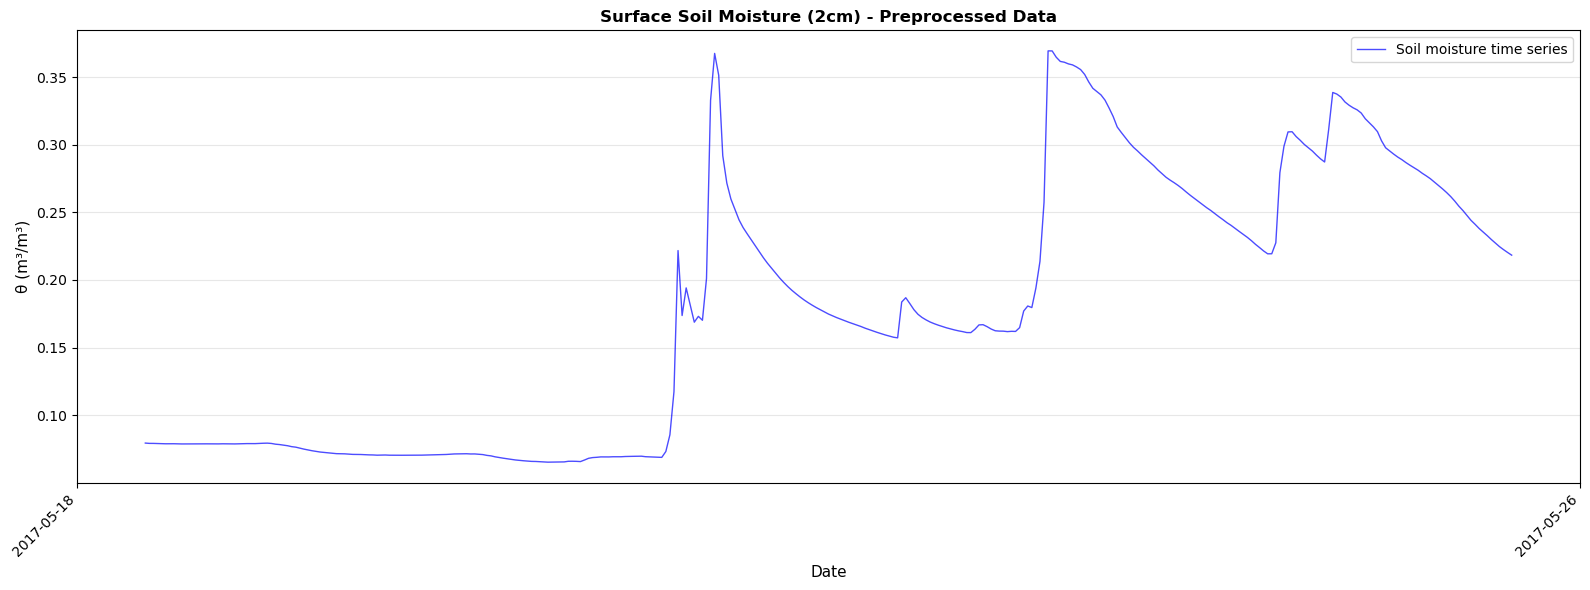


Data Summary for Surface (2cm):
  Total points:        337
  Valid points:        337
  Missing (NaN):       0
  Data completeness:   100.0%
  Moisture range:      0.0652 - 0.3694 m³/m³

DATA LOADING COMPLETE
✓ Loaded from: ../data/2017_HalfHourly_UTC_ForestSite1.xlsx
✓ Date range: 2017-05-19 to 2017-05-26
✓ To switch datasets, change config_file variable and re-run this cell


In [14]:
# ============================================================================
# LOAD SOIL MOISTURE DATA USING CONFIG FILE
# ============================================================================
# This cell uses Simple Config Mapping to load any dataset via YAML config
# To switch datasets, just change the config_file variable below!
# ============================================================================

from src.config_loader import load_config
from src.data_preprocessing import preprocess_soil_data
import matplotlib.dates as mdates

# ============================================================================
# CONFIG FILE SELECTION - Choose your dataset here:
# ============================================================================
# Option 1: Calhoun CCZO data (default)
config_file = '../configs/baseline.yaml'

# Option 2: US-Uaf data (uncomment to use)
# config_file = '../configs/us_uaf_2019.yaml'

# Option 3: Your own dataset (create a new config file first)
# config_file = '../configs/your_dataset.yaml'

print("="*70)
print("LOADING DATA USING SIMPLE CONFIG MAPPING")
print("="*70)
print(f"Config file: {config_file}")

# Load configuration
config = load_config(config_file)

# Fix data path if running from notebook (config paths are relative to project root)
if not os.path.isabs(config.data_path) and not os.path.exists(config.data_path):
    # Try prepending ../ for notebook context
    test_path = os.path.join('..', config.data_path)
    if os.path.exists(test_path):
        # Temporarily modify the config's internal data path
        config._config['data']['path'] = test_path
        print(f"Note: Adjusted data path for notebook context: {test_path}")

# Preprocess data using config (handles column mapping automatically)
preprocessed_data = preprocess_soil_data(config, output_path='../data/preprocessed_soil_data.pkl')

# Extract data
datetime_col = preprocessed_data['datetime_col']
times_seconds = preprocessed_data['times_seconds']

# Get available depths from the preprocessed data
available_depths = [key.replace('theta_', '') for key in preprocessed_data.keys() if key.startswith('theta_')]
print(f"\nAvailable depths: {available_depths}")

# Extract theta values for each depth (handles variable number of depths)
theta_2cm = preprocessed_data.get('theta_2cm')
theta_15cm = preprocessed_data.get('theta_15cm')
theta_30cm = preprocessed_data.get('theta_30cm')
theta_40cm = preprocessed_data.get('theta_40cm')
theta_60cm = preprocessed_data.get('theta_60cm')
theta_80cm = preprocessed_data.get('theta_80cm')

# Build depths_names list from available data
depths_names = []
theta_depths_dict = {}
for depth_name in ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']:
    key = f'theta_{depth_name}'
    if key in preprocessed_data:
        depths_names.append(depth_name)
        theta_depths_dict[depth_name] = preprocessed_data[key]

print(f"Loaded depths: {depths_names}")
print(f"Data points: {len(times_seconds)}")
print(f"Duration: {times_seconds[-1]/86400:.1f} days")

# ============================================================================
# VISUALIZE INTERPOLATION QUALITY (SURFACE LAYER)
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING INTERPOLATION QUALITY (Surface layer)")
print("="*70)

# Use the first available depth as surface layer
if theta_2cm is not None:
    theta_surface = theta_2cm
    surface_depth_name = '2cm'
elif len(depths_names) > 0:
    surface_depth_name = depths_names[0]
    theta_surface = theta_depths_dict[surface_depth_name]
else:
    raise ValueError("No depth data available!")

# For visualization, we'll just show the cleaned data
# (preprocessing already handles interpolation)
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

# Plot cleaned time series
valid_mask = ~pd.isna(theta_surface)
still_nan_mask = pd.isna(theta_surface)

ax.plot(datetime_col, theta_surface, linewidth=1, alpha=0.7, color='blue', label='Soil moisture time series')
if still_nan_mask.any():
    ax.scatter(datetime_col[still_nan_mask], np.full(still_nan_mask.sum(), np.nanmean(theta_surface)),
               s=20, alpha=0.5, color='red', marker='x', label=f'Missing ({still_nan_mask.sum()})', zorder=5)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('θ (m³/m³)', fontsize=11)
ax.set_title(f'Surface Soil Moisture ({surface_depth_name}) - Preprocessed Data', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nData Summary for Surface ({surface_depth_name}):")
print(f"  Total points:        {len(theta_surface)}")
print(f"  Valid points:        {valid_mask.sum()}")
print(f"  Missing (NaN):       {still_nan_mask.sum()}")
print(f"  Data completeness:   {(valid_mask.sum()/len(theta_surface)*100):.1f}%")
print(f"  Moisture range:      {np.nanmin(theta_surface):.4f} - {np.nanmax(theta_surface):.4f} m³/m³")

print("\n" + "="*70)
print("DATA LOADING COMPLETE")
print("="*70)
print(f"✓ Loaded from: {config.data_path}")
print(f"✓ Date range: {config.start_date} to {config.end_date}")
print(f"✓ To switch datasets, change config_file variable and re-run this cell")
print("="*70)


THREE-WAY GRADIENT-BASED SAMPLING TEST - SURFACE MOISTURE

Gradient Statistics:
  Max |dθ/dt|:  7.321e-05 m³/m³/s
  Mean |dθ/dt|: 2.309e-06 m³/m³/s
  Min |dθ/dt|:  0.000e+00 m³/m³/s

High-gradient points (top 30%): 101

Generated 450 gradient-weighted samples
Sample range: [0.0, 604800.0] s

Sample Breakdown:
  Interpolated:  135 (30.0%)
  Neighbors:     0 (0.0%)
  Baseline:      315 (70.0%)

VISUALIZATION 1: Three-Way Gradient Sampling Details


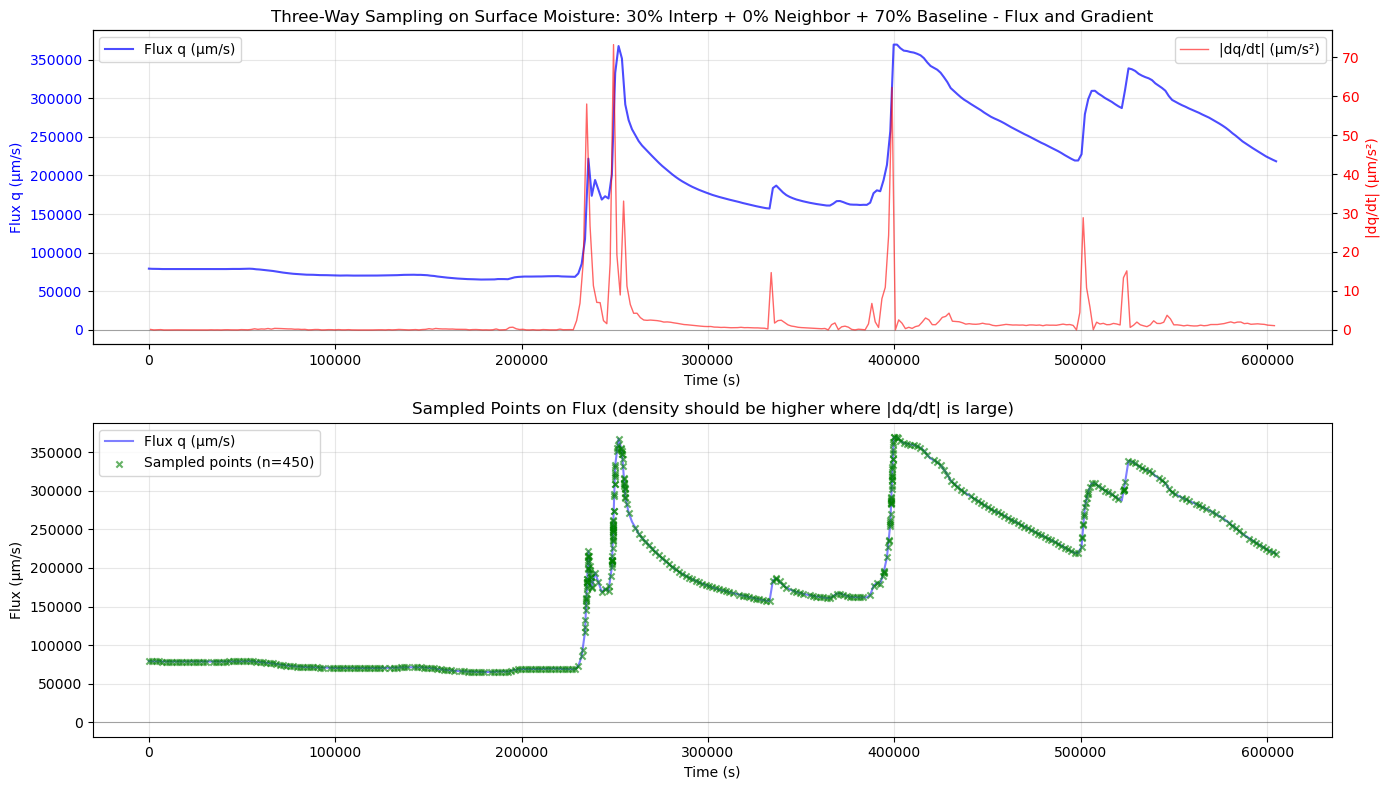


VISUALIZATION 2: Uniform vs Gradient-Based Comparison


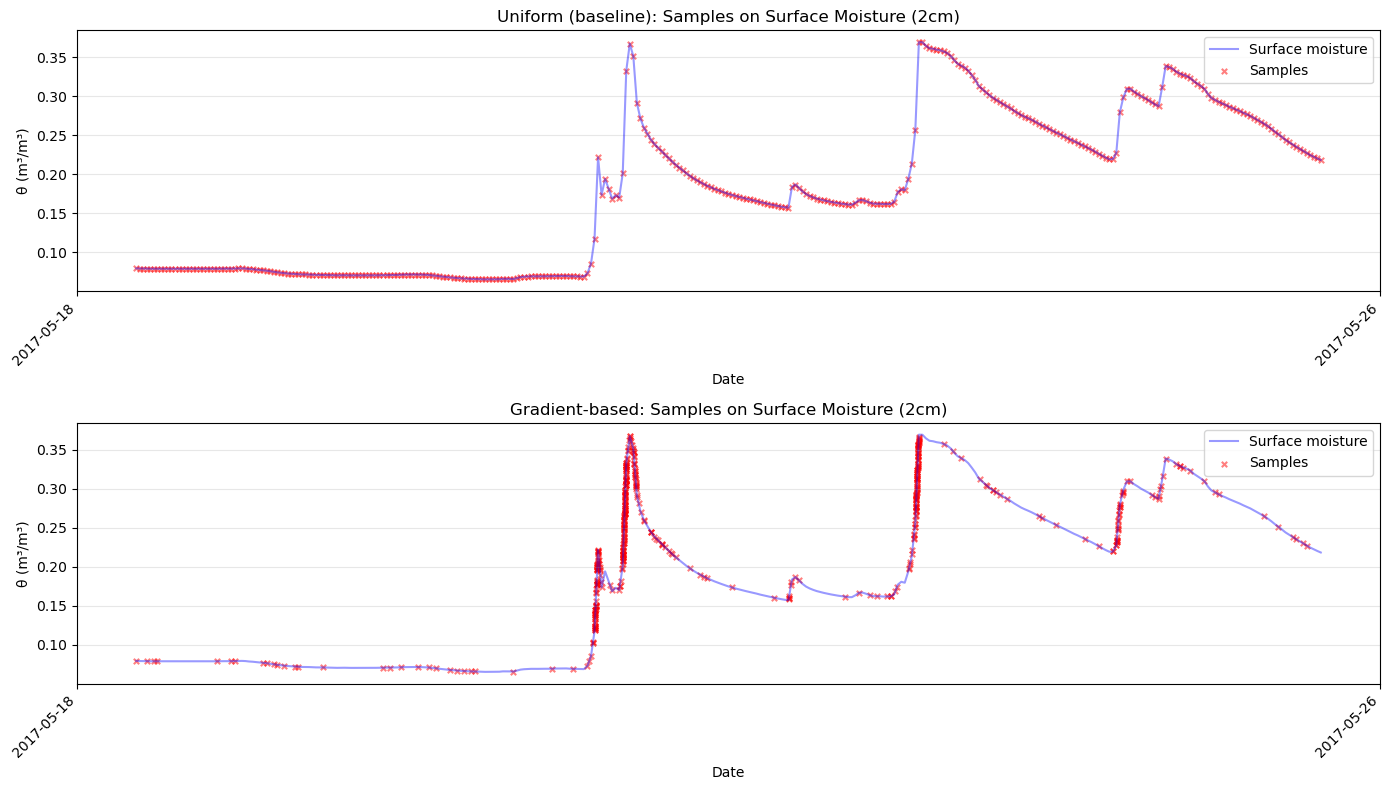


QUANTITATIVE VERIFICATION
Configuration: 30% interp + 0% neighbor + 70% baseline

Gradient Enrichment:
  Average |dθ/dt| at sampled points:  1.144e-05 m³/m³/s
  Average |dθ/dt| overall:            2.309e-06 m³/m³/s
  Enrichment factor:                  4.95x

Sample Composition:
  Interpolated points:  135
  Neighbor points:      0
  Baseline points:      315

Expected: Enrichment > 1.5x (samples concentrated in high-gradient regions)
  → Regions with rapid moisture changes (drying/wetting events)


In [15]:
# ============================================================================
# TEST THREE-WAY GRADIENT-BASED SAMPLING ON SURFACE MOISTURE DATA
# ============================================================================

from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compare_sampling_methods,
    compute_gradient_weights
)

# Prepare surface moisture data for sampling
theta_surface = theta_2cm.copy()
times_surface = times_seconds.copy()

# Remove NaN values for gradient-based sampling
valid_mask = ~pd.isna(theta_surface)
theta_clean = theta_surface[valid_mask]
times_clean = times_surface[valid_mask]
datetime_clean = datetime_col[valid_mask]

# Convert to tensors - ensure numeric type
theta0_times_t = torch.tensor(np.array(times_clean, dtype=np.float32), dtype=torch.float32).to(device)
theta0_values = torch.tensor(np.array(theta_clean, dtype=np.float32), dtype=torch.float32).to(device)

print("\n" + "="*70)
print("THREE-WAY GRADIENT-BASED SAMPLING TEST - SURFACE MOISTURE")
print("="*70)

# Compute gradient weights
gradient_weights, gradients = compute_gradient_weights(theta0_times_t, theta0_values, device)

print(f"\nGradient Statistics:")
print(f"  Max |dθ/dt|:  {gradients.abs().max().item():.3e} m³/m³/s")
print(f"  Mean |dθ/dt|: {gradients.abs().mean().item():.3e} m³/m³/s")
print(f"  Min |dθ/dt|:  {gradients.abs().min().item():.3e} m³/m³/s")

# Find high-gradient regions
high_grad_threshold = gradients.abs().quantile(0.7)  # Top 30%
high_grad_mask = gradients.abs() > high_grad_threshold
print(f"\nHigh-gradient points (top 30%): {high_grad_mask.sum().item()}")

# Test parameters - THREE-WAY SAMPLING
batch_size_bc = 450
interp_ratio = 0.30      # 80% from gradient-interpolated points
neighbor_ratio = 0.00    # 5% from neighbors of high-gradient regions
baseline_ratio = 0.7    # 15% from uniform baseline
neighbor_expansion = 0   # ±2 neighbors around high gradients
power = 2.0              # >1 emphasizes high gradients more aggressively
gradient_threshold = 0.7

# Generate three-way gradient-based samples
t_bc_gradient, sample_info = gradient_based_sampling(
    theta0_times_t,
    theta0_values,
    batch_size_bc,
    device=device,
    use_interpolation=True,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    power=power
)

print(f"\nGenerated {len(t_bc_gradient)} gradient-weighted samples")
print(f"Sample range: [{t_bc_gradient.min():.1f}, {t_bc_gradient.max():.1f}] s")
print(f"\nSample Breakdown:")
print(f"  Interpolated:  {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:     {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:      {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 1: Three-Way Gradient Sampling Details")
print("="*70)
visualize_gradient_sampling(
    theta0_times_t,
    theta0_values,
    t_bc_gradient,
    sample_info,
    title=f'Three-Way Sampling on Surface Moisture: {interp_ratio*100:.0f}% Interp + {neighbor_ratio*100:.0f}% Neighbor + {baseline_ratio*100:.0f}% Baseline'
)
plt.show()

# Compare uniform vs gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 2: Uniform vs Gradient-Based Comparison")
print("="*70)

configs = [
    {"name": "Uniform (baseline)", "interp": 0.0, "neighbor": 0.0, "baseline": 1.0},
    {"name": "Gradient-based", "interp": 0.80, "neighbor": 0.05, "baseline": 0.15},
]

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 4*len(configs)))
if len(configs) == 1:
    axes = [axes]

for i, config in enumerate(configs):
    # Generate samples
    if config['interp'] == 0.0:
        # Pure uniform
        uniform_idx = torch.randperm(len(theta0_times_t), device=device)[:batch_size_bc]
        t_bc_test = theta0_times_t[uniform_idx]
    else:
        t_bc_test, info_test = gradient_based_sampling(
            theta0_times_t, theta0_values, batch_size_bc, device=device,
            use_interpolation=(config['interp'] > 0),
            interp_ratio=config['interp'],
            neighbor_ratio=config['neighbor'],
            baseline_ratio=config['baseline'],
            neighbor_expansion=2,
            gradient_threshold=0.7,
            power=power
        )

    samples_np = t_bc_test.detach().cpu().numpy().flatten()
    times_np = theta0_times_t.cpu().numpy().flatten()
    values_np = theta0_values.cpu().numpy().flatten()

    # Convert times to datetime for plotting
    datetime_samples = datetime_clean.iloc[0] + pd.to_timedelta(samples_np, unit='s')
    
    # Scatter on moisture
    ax = axes[i]
    ax.plot(datetime_clean, values_np, 'b-', linewidth=1.5, alpha=0.4, label='Surface moisture')
    ax.scatter(datetime_samples, np.interp(samples_np, times_np, values_np),
            s=15, c='red', alpha=0.5, marker='x', label='Samples')
    ax.set_ylabel('θ (m³/m³)')
    ax.set_xlabel('Date')
    ax.set_title(f"{config['name']}: Samples on Surface Moisture (2cm)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Quantitative verification
print("\n" + "="*70)
print("QUANTITATIVE VERIFICATION")
print("="*70)

# Check if samples are concentrated in high-gradient regions
samples_np = t_bc_gradient.detach().cpu().numpy().flatten()
times_np = theta0_times_t.cpu().numpy().flatten()

# For each sample, find nearest data point and check its gradient
sample_gradients = []
for s in samples_np:
    idx = torch.argmin(torch.abs(theta0_times_t.flatten() - s))
    if idx < len(gradients):
        sample_gradients.append(gradients[idx].abs().item())

sample_grad_mean = np.mean(sample_gradients)
overall_grad_mean = gradients.abs().mean().item()

print(f"Configuration: {interp_ratio*100:.0f}% interp + {neighbor_ratio*100:.0f}% neighbor + {baseline_ratio*100:.0f}% baseline")
print(f"\nGradient Enrichment:")
print(f"  Average |dθ/dt| at sampled points:  {sample_grad_mean:.3e} m³/m³/s")
print(f"  Average |dθ/dt| overall:            {overall_grad_mean:.3e} m³/m³/s")
print(f"  Enrichment factor:                  {sample_grad_mean/overall_grad_mean:.2f}x")
print(f"\nSample Composition:")
print(f"  Interpolated points:  {sample_info['n_interp_samples']}")
print(f"  Neighbor points:      {sample_info['n_neighbor_samples']}")
print(f"  Baseline points:      {sample_info['n_baseline_samples']}")
print("\nExpected: Enrichment > 1.5x (samples concentrated in high-gradient regions)")
print("  → Regions with rapid moisture changes (drying/wetting events)")
print("="*70)

PROCESSING THETA DATA AT ALL DEPTHS
Soil parameters:
  theta_s: 0.4
  theta_r: 0.01
  alpha: 0.4
  n: 1.7
  Ks: 1e-05
  l: 0.5


NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.390
Time scale (T):             1.56e+05 s (43.33 hours)
Dimensionless α̃:            1.6000
Dimensionless S̃_max:        0.0400



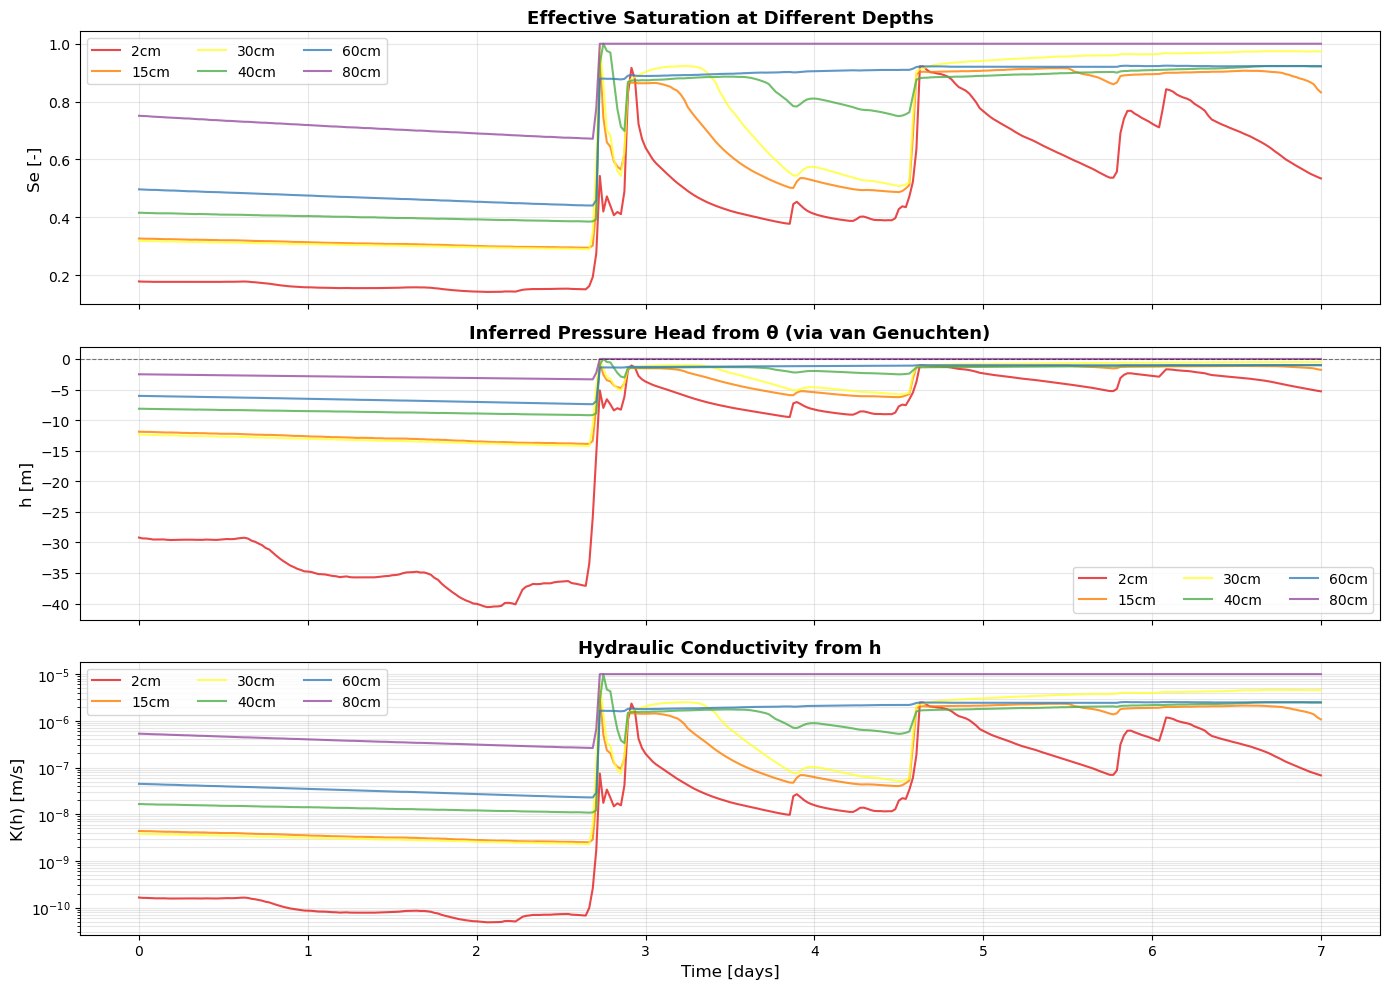


STATISTICS BY DEPTH

2cm:
  Se range:    0.1416 - 0.9214
  h range:     -40.5803 - -1.0257 m
  K range:     4.833e-11 - 2.459e-06 m/s
  Data points: 337

15cm:
  Se range:    0.2946 - 0.9671
  h range:     -13.8901 - -0.5847 m
  K range:     2.508e-09 - 4.158e-06 m/s
  Data points: 337

30cm:
  Se range:    0.2898 - 0.9909
  h range:     -14.2368 - -0.2682 m
  K range:     2.294e-09 - 6.249e-06 m/s
  Data points: 337

40cm:
  Se range:    0.3847 - 1.0000
  h range:     -9.2069 - 0.0000 m
  K range:     1.079e-08 - 1.000e-05 m/s
  Data points: 337

60cm:
  Se range:    0.4406 - 0.9242
  h range:     -7.3950 - -1.0010 m
  K range:     2.287e-08 - 2.530e-06 m/s
  Data points: 337

80cm:
  Se range:    0.6712 - 1.0000
  h range:     -3.3366 - 0.0000 m
  K range:     2.611e-07 - 1.000e-05 m/s
  Data points: 337


In [16]:
# Time series of Se_obs, h inferred from Se, and K(h) from theta data at ALL DEPTHS
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.normalization_helper import NormalizationHelper
from src.config_loader import load_config

# Ensure config is loaded (in case it was overwritten)
if not hasattr(config, 'soil_params'):
    # Config was overwritten, reload it
    config = load_config(config_file)

# Get soil parameters from config
soil_params = config.soil_params

# Use soil parameters from config (already loaded)
print("="*70)
print("PROCESSING THETA DATA AT ALL DEPTHS")
print("="*70)
print("Soil parameters:")
for key, val in soil_params.items():
    print(f"  {key}: {val}")
print()

# Initialize normalization helper (use same L, S_max from config)
L = config.L
S_max = config.S_max
normalizer = NormalizationHelper(soil_params, L=L, S_max=S_max)

# ============================================================================
# PROCESS ALL DEPTH LEVELS
# ============================================================================

# Collect theta data from all available depths
theta_depths = {}
for depth_name in depths_names:
    theta_depths[depth_name] = theta_depths_dict[depth_name]

# Colors for different depths (reuse for up to 6 depths)
colors = ['#e41a1c', '#ff7f00', '#ffff33', '#4daf4a', '#377eb8', '#984ea3']

# Storage for all depths
all_results = {}

for i, depth_name in enumerate(depths_names):
    theta_vals = theta_depths[depth_name]
    
    # Get valid data
    valid_mask = ~pd.isna(theta_vals)
    times_sec = times_seconds[valid_mask]
    theta_clean = theta_vals[valid_mask]
    
    # Convert to numpy
    times_sec = np.array(times_sec, dtype=np.float64)
    theta_clean = np.array(theta_clean, dtype=np.float64)
    
    if len(theta_clean) == 0:
        print(f"Warning: No valid data for {depth_name}")
        continue
    
    # Compute Se_obs = (theta - theta_r) / (theta_s - theta_r)
    theta_r = normalizer.theta_r
    theta_star = normalizer.theta_star
    Se_obs = np.clip((theta_clean - theta_r) / theta_star, 1e-6, 1.0 - 1e-6)
    
    # Invert van Genuchten to estimate h (unsaturated: h < 0). For Se≈1, set h = 0.
    alpha_tilde = normalizer.alpha_tilde
    n_vg = normalizer.n
    m_vg = normalizer.m
    
    Se_t = torch.tensor(Se_obs, dtype=torch.float32).view(-1, 1)
    with torch.no_grad():
        # h_tilde = - ((Se^{-1/m} - 1)^{1/n}) / alpha_tilde, for Se in (0,1)
        inv_term = torch.pow(torch.clamp(Se_t, 1e-6, 1.0 - 1e-6), -1.0 / m_vg) - 1.0
        h_tilde_unsat = - torch.pow(torch.clamp(inv_term, min=0.0), 1.0 / n_vg) / float(alpha_tilde)
        # If Se very close to 1 (>= 1 - eps), assume saturated at h = 0
        eps = 1e-6
        sat_mask = (Se_t >= 1.0 - eps)
        h_tilde = torch.where(sat_mask, torch.zeros_like(h_tilde_unsat), h_tilde_unsat)
        
        # Convert to dimensional head h [m]
        h_dim = normalizer.denormalize_h(h_tilde)
        
        # Compute K_tilde(h) and dimensional K(h)
        K_rel = normalizer.K_tilde(h_tilde)
        Ks = soil_params['Ks']
        K_dim = K_rel * Ks
    
    h_series = h_dim.cpu().numpy().flatten()
    K_series = K_dim.cpu().numpy().flatten()
    t_days = times_sec / 86400.0
    
    all_results[depth_name] = {
        't_days': t_days,
        'Se': Se_obs,
        'h': h_series,
        'K': K_series,
    }

# ============================================================================
# PLOT ALL DEPTHS
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Se for all depths
for i, depth_name in enumerate(depths_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        color_idx = i % len(colors)  # Cycle through colors if more than 6 depths
        axes[0].plot(data['t_days'], data['Se'], color=colors[color_idx], 
                    label=depth_name, linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Se [-]', fontsize=12)
axes[0].set_title('Effective Saturation at Different Depths', fontsize=13, fontweight='bold')
axes[0].legend(ncol=3, fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: h for all depths
for i, depth_name in enumerate(depths_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        color_idx = i % len(colors)
        axes[1].plot(data['t_days'], data['h'], color=colors[color_idx], 
                    label=depth_name, linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('h [m]', fontsize=12)
axes[1].set_title('Inferred Pressure Head from θ (via van Genuchten)', fontsize=13, fontweight='bold')
axes[1].axhline(0.0, color='k', linewidth=0.8, alpha=0.5, linestyle='--')
axes[1].legend(ncol=3, fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

# Plot 3: K for all depths
for i, depth_name in enumerate(depths_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        color_idx = i % len(colors)
        axes[2].semilogy(data['t_days'], np.maximum(data['K'], 1e-12), 
                        color=colors[color_idx], label=depth_name, linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('K(h) [m/s]', fontsize=12)
axes[2].set_title('Hydraulic Conductivity from h', fontsize=13, fontweight='bold')
axes[2].legend(ncol=3, fontsize=10, loc='best')
axes[2].grid(True, which='both', alpha=0.3)
axes[2].set_xlabel('Time [days]', fontsize=12)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*70)
print("STATISTICS BY DEPTH")
print("="*70)
for depth_name in depths_names:
    if depth_name in all_results:
        data = all_results[depth_name]
        print(f"\n{depth_name}:")
        print(f"  Se range:    {data['Se'].min():.4f} - {data['Se'].max():.4f}")
        print(f"  h range:     {data['h'].min():.4f} - {data['h'].max():.4f} m")
        print(f"  K range:     {data['K'].min():.3e} - {data['K'].max():.3e} m/s")
        print(f"  Data points: {len(data['t_days'])}")
print("="*70)

In [17]:
# ============================================================================
# PREPARE INITIAL CONDITION FROM MEASURED THETA PROFILE
# ============================================================================

# Use the IC profile that was already prepared during preprocessing
ic_profile = preprocessed_data['ic_profile']

print("="*70)
print("INITIAL CONDITION FROM MEASURED THETA PROFILE")
print("="*70)
print(f"IC Profile has {len(ic_profile['depths'])} measurement points:")
for depth_m, theta_val in zip(ic_profile['depths'], ic_profile['theta']):
    depth_cm = depth_m * 100
    print(f"  {depth_cm:6.1f}cm: θ = {theta_val:.4f} m³/m³")
print("="*70 + "\n")

# ============================================================================
# PREPARE MOISTURE BC DATA
# ============================================================================

# Use soil parameters from config
soil_params = config.soil_params
print("Soil parameters from config:")
for key, val in soil_params.items():
    print(f"  {key}: {val}")
print()

# Prepare theta0_data tuple for training (times, moisture values)
# Use the surface layer (first depth)
if theta_2cm is not None:
    theta_surface_bc = theta_2cm
elif len(depths_names) > 0:
    theta_surface_bc = theta_depths_dict[depths_names[0]]
else:
    raise ValueError("No surface moisture data available!")

# Remove NaN values from surface moisture data
valid_mask = ~pd.isna(theta_surface_bc)
theta0_times = times_seconds[valid_mask]
theta0_values = theta_surface_bc[valid_mask]

# Convert to numpy arrays to ensure proper type
theta0_times = np.array(theta0_times, dtype=np.float64)
theta0_values = np.array(theta0_values, dtype=np.float64)

theta0_data = (theta0_times, theta0_values)

print("="*70)
print("TRAINING WITH MOISTURE BC (Dirichlet)")
print("  Surface BC: θ(z=0, t) = θ₀(t)")
print(f"  Data points: {len(theta0_data[0])}")
print(f"  Duration: {theta0_data[0][-1]/86400:.1f} days")
print(f"  Moisture range: {min(theta0_data[1]):.4f} - {max(theta0_data[1]):.4f} m³/m³")
print(f"  Soil: θr={soil_params['theta_r']:.3f}, θs={soil_params['theta_s']:.3f}")
print("="*70 + "\n")

# ============================================================================
# TRAINING CONFIGURATION - MOISTURE BC WITH MEASURED IC
# ============================================================================

# Get network configurations from config
h_net_config = config.h_net_config
zb_net_config = config.zb_net_config

print(f"Network configurations:")
print(f"  h_net:  {h_net_config}")
print(f"  zb_net: {zb_net_config}")
print()

# ============================================================================
# CHOOSE INITIAL CONDITION TYPE
# ============================================================================
# Options:
#   'obs'        - Use measured profile with linear extrapolation to water table
#   'linear'     - Simple linear from surface h_obs to water table h=0
#   'hydrostatic' - Hydrostatic profile (h = -zb - z)
ic_type = config.ic_type  # Get from config, or override here

print(f"Using IC type: {ic_type} (from config)")
print("  (You can override by setting ic_type = 'obs', 'linear', or 'hydrostatic')")
print("="*70 + "\n")

# ============================================================================
# TRAIN PINN WITH MOISTURE BC AND MEASURED IC PROFILE
# ============================================================================

print("Starting PINN Training with Moisture BC and Measured IC")
print("="*70)

# Get sampling parameters from config
batch_size_bc = config.batch_size_bc
interp_ratio = config.interp_ratio
neighbor_ratio = config.neighbor_ratio
baseline_ratio = config.baseline_ratio
neighbor_expansion = config.gradient_neighbor_expansion
gradient_threshold = config.gradient_threshold
power = config.gradient_power

print(f"Gradient-based BC sampling config:")
print(f"  Batch size: {batch_size_bc}")
print(f"  Interp ratio: {interp_ratio}")
print(f"  Neighbor ratio: {neighbor_ratio}")
print(f"  Baseline ratio: {baseline_ratio}")
print()

# Train with pool + batch approach using gradient-based boundary sampling
model_pool, losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs = train_pinn_pool_batch_autoweight(
    soil_params=soil_params,
    theta0_data=theta0_data,  # Moisture BC data - REQUIRED
    Sy=config.Sy,
    zr=config.zr,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    L=config.L,
    S_max=config.S_max,
    n_epochs=config.n_epochs,
    learning_rate=config.learning_rate,
    zb_initial=config.zb_initial,
    weight_update_freq=config.weight_update_freq,
    weight_lr=config.weight_lr,
    use_initial_scales=config.use_initial_scales,
    
    # Pool + batch parameters
    cache_size=config.cache_size,
    batch_size=config.batch_size,
    resample_freq=config.resample_freq,
    boundary_ratio=config.boundary_ratio,
    high_residual_ratio=config.high_residual_ratio,
    temperature=config.temperature,
    
    # Gradient-based boundary sampling parameters
    batch_size_bc=batch_size_bc,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    gradient_neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    gradient_power=power,
    
    # Measured initial condition profile
    ic_profile=ic_profile,  # ← Measured theta profile
    ic_type=ic_type,        # ← IC type: 'obs', 'linear', or 'hydrostatic'
    
    # Device and checkpointing
    device=device,
    checkpoint_dir='../checkpoints_train',
    checkpoint_freq=config.checkpoint_freq,
)

print("\n" + "="*70)
print("Training Complete!")
print("="*70)

INITIAL CONDITION FROM MEASURED THETA PROFILE
IC Profile has 6 measurement points:
     2.0cm: θ = 0.0794 m³/m³
    15.0cm: θ = 0.1372 m³/m³
    30.0cm: θ = 0.1342 m³/m³
    40.0cm: θ = 0.1720 m³/m³
    60.0cm: θ = 0.2036 m³/m³
    80.0cm: θ = 0.3028 m³/m³

Soil parameters from config:
  theta_s: 0.4
  theta_r: 0.01
  alpha: 0.4
  n: 1.7
  Ks: 1e-05
  l: 0.5

TRAINING WITH MOISTURE BC (Dirichlet)
  Surface BC: θ(z=0, t) = θ₀(t)
  Data points: 337
  Duration: 7.0 days
  Moisture range: 0.0652 - 0.3694 m³/m³
  Soil: θr=0.010, θs=0.400

Network configurations:
  h_net:  {'hidden_dim': 64, 'num_layers': 4}
  zb_net: {'hidden_dim': 32, 'num_layers': 3}

Using IC type: obs (from config)
  (You can override by setting ic_type = 'obs', 'linear', or 'hydrostatic')

Starting PINN Training with Moisture BC and Measured IC
Gradient-based BC sampling config:
  Batch size: 450
  Interp ratio: 0.3
  Neighbor ratio: 0.0
  Baseline ratio: 0.7


NORMALIZATION SCALES
Length scale (L):           4.000 m
H

VISUALIZING TRAINED MODEL

VISUALIZING MODEL WITH 6 DEPTH OBSERVATIONS


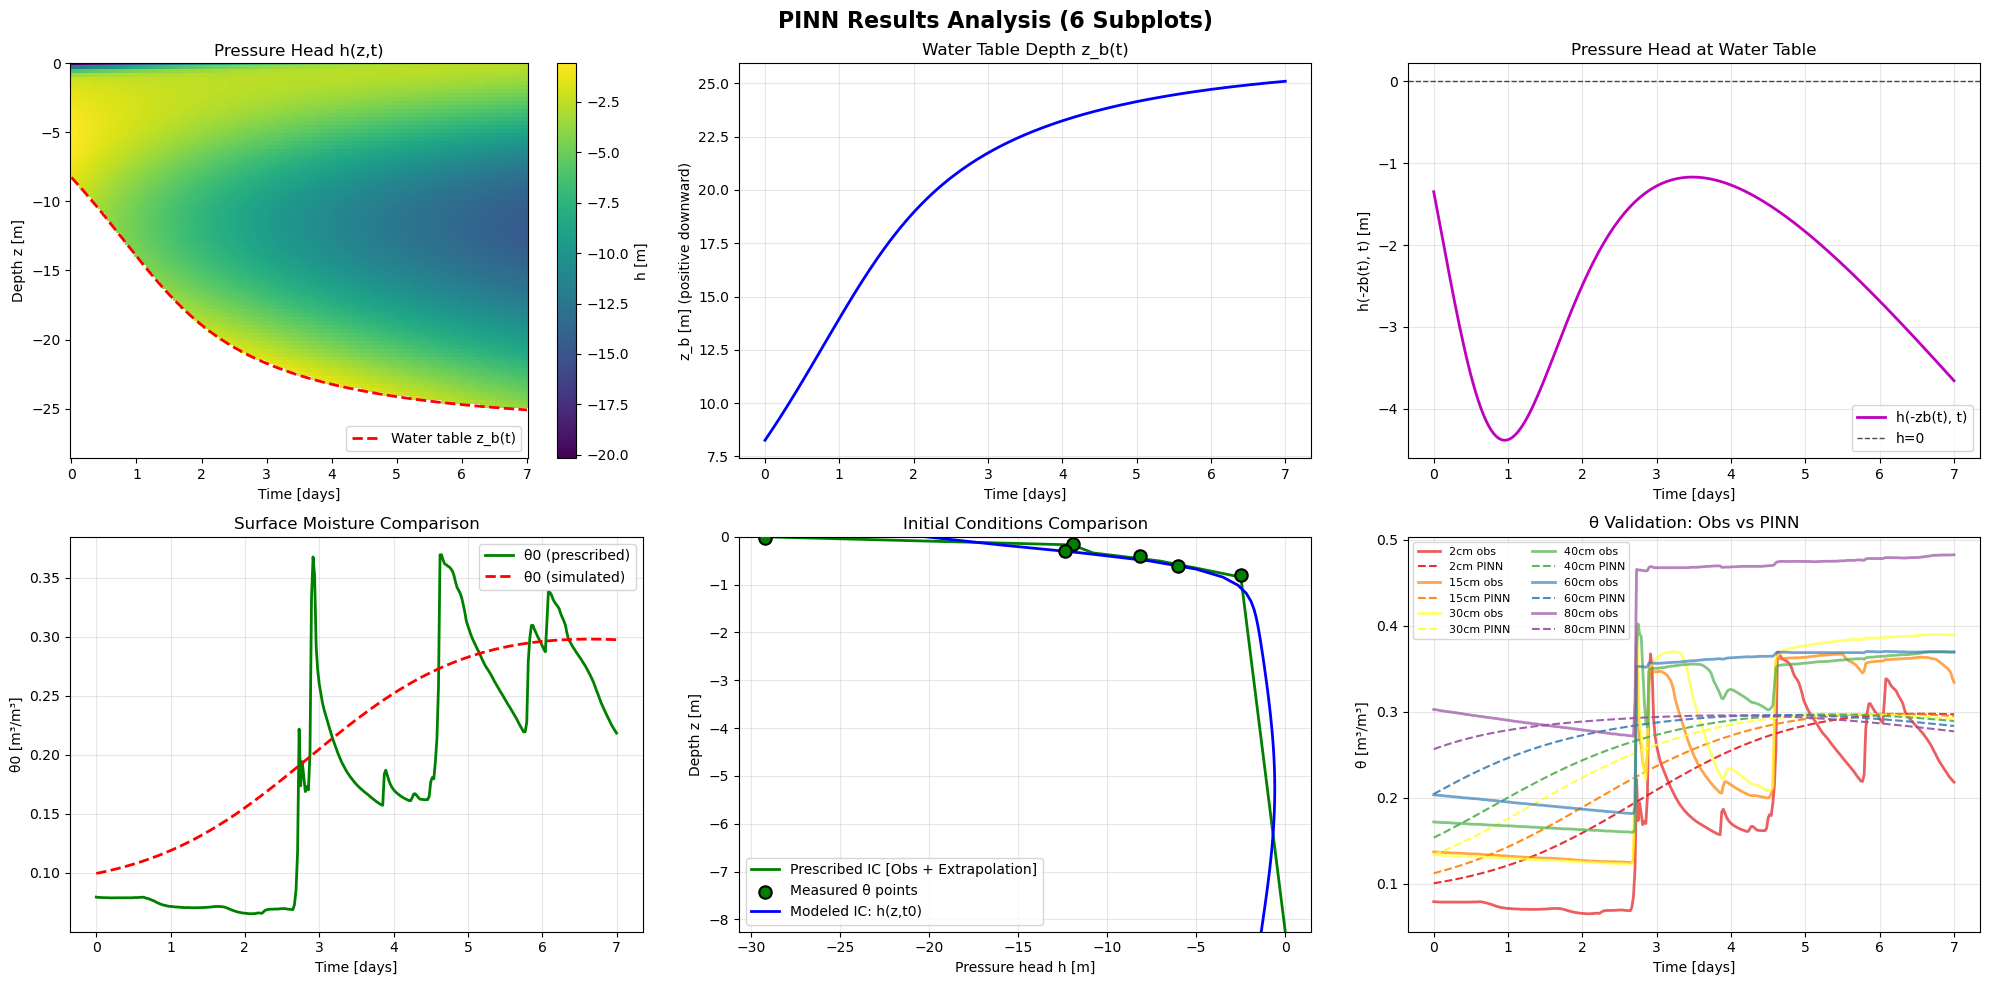


Summary Statistics:
Water table depth range: 8.259 to 25.093 m
Surface head range: -20.167 to -2.630 m
h(-zb(t), t) range: -4.384666 to -1.170089 m
Max |h(-zb(t), t)|: 4.384666 m (should be close to 0)
Max IC error: 9.040321 m

Theta Validation Statistics:
    2cm: RMSE = 0.065553 m³/m³, MAE = 0.056269 m³/m³
   15cm: RMSE = 0.060798 m³/m³, MAE = 0.053903 m³/m³
   30cm: RMSE = 0.078775 m³/m³, MAE = 0.072273 m³/m³
   40cm: RMSE = 0.063257 m³/m³, MAE = 0.057073 m³/m³
   60cm: RMSE = 0.071230 m³/m³, MAE = 0.068351 m³/m³
   80cm: RMSE = 0.143629 m³/m³, MAE = 0.118014 m³/m³


In [18]:
# ============================================================================
# VISUALIZE TRAINED MODEL FROM ABOVE CELL
# ============================================================================

from src.visualization import plot_comprehensive_results

print("="*70)
print("VISUALIZING TRAINED MODEL")
print("="*70)

# Use the model_pool that was just trained in the cell above
model_pool.eval()

# Prepare observation data for theta validation subplot
# Build depths and theta arrays dynamically from available data
obs_depths = []
obs_theta = []
for depth_name in depths_names:
    # Convert depth name to meters (negative for plotting)
    if depth_name.endswith('cm'):
        depth_m = -float(depth_name[:-2]) / 100.0
    elif depth_name.endswith('m'):
        depth_m = -float(depth_name[:-1])
    else:
        continue
    
    obs_depths.append(depth_m)
    obs_theta.append(theta_depths_dict[depth_name])

obs_data_viz = {
    'times': times_seconds,  # Full time array for all depths
    'depths': obs_depths,    # Negative depths in meters
    'theta': obs_theta       # Theta values for each depth
}

# Visualize the trained model
print("\n" + "="*70)
print(f"VISUALIZING MODEL WITH {len(obs_depths)} DEPTH OBSERVATIONS")
print("="*70)

plot_comprehensive_results(model_pool, theta0_data, soil_params, device=device, obs_data=obs_data_viz)

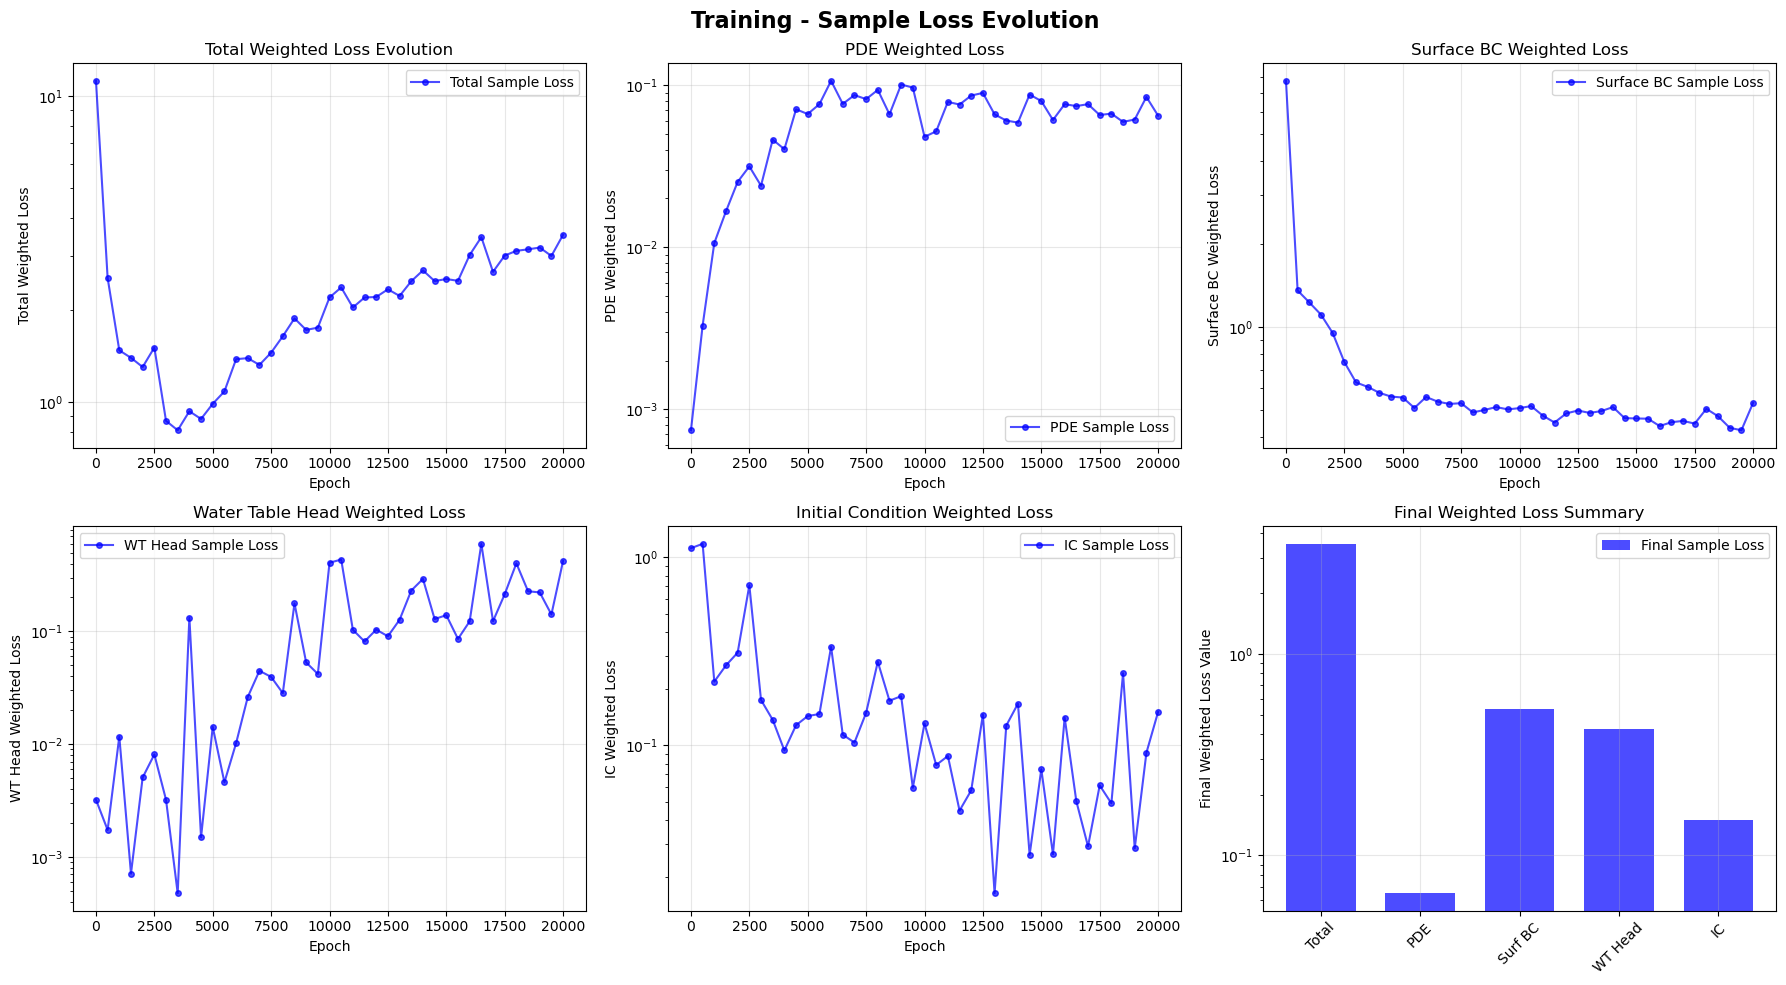

In [19]:
# Import and use the loss plotting function from external module
from src.visualization import plot_training_losses

# Plot the sample losses (computed over full dataset every 500 epochs)
# This gives a smoother, less noisy view of the loss evolution
plot_training_losses(losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs)